# Extended Data Fig. 3

PacBio phasing and per-haplotype methylation, the expert's run against the agent's.

In [1]:
import sys; sys.path.insert(0, "../scripts"); sys.path.insert(0, "../scripts/paper")
from pathlib import Path
from nbkit import setup, paper_py, paper_r, run_r_source, harvest, show, have_r_package, DATA

OUT = setup("../figures/notebook")
print("panels will be written to", OUT)

# %%R cells below run R natively in this kernel through rpy2, so the R panels are R code
# in the notebook rather than a string that gets written to a file.
%load_ext rpy2.ipython

panels will be written to ./figures/notebook


## The two PacBio phasing arms

The same script again, on the phasing arms.

font: DejaVu Sans
{
  "font_used": "DejaVu Sans",
  "human": "supp4_human",
  "agents": [
    "supp4_agent"
  ],
  "icr_haplotype": {
    "supp4_agent": {
      "values": 11,
      "pearson_r": 1.0,
      "max_abs_difference": 0.0
    }
  }
}
panels -> ./data/runs/figure3/panels
2 panels collected


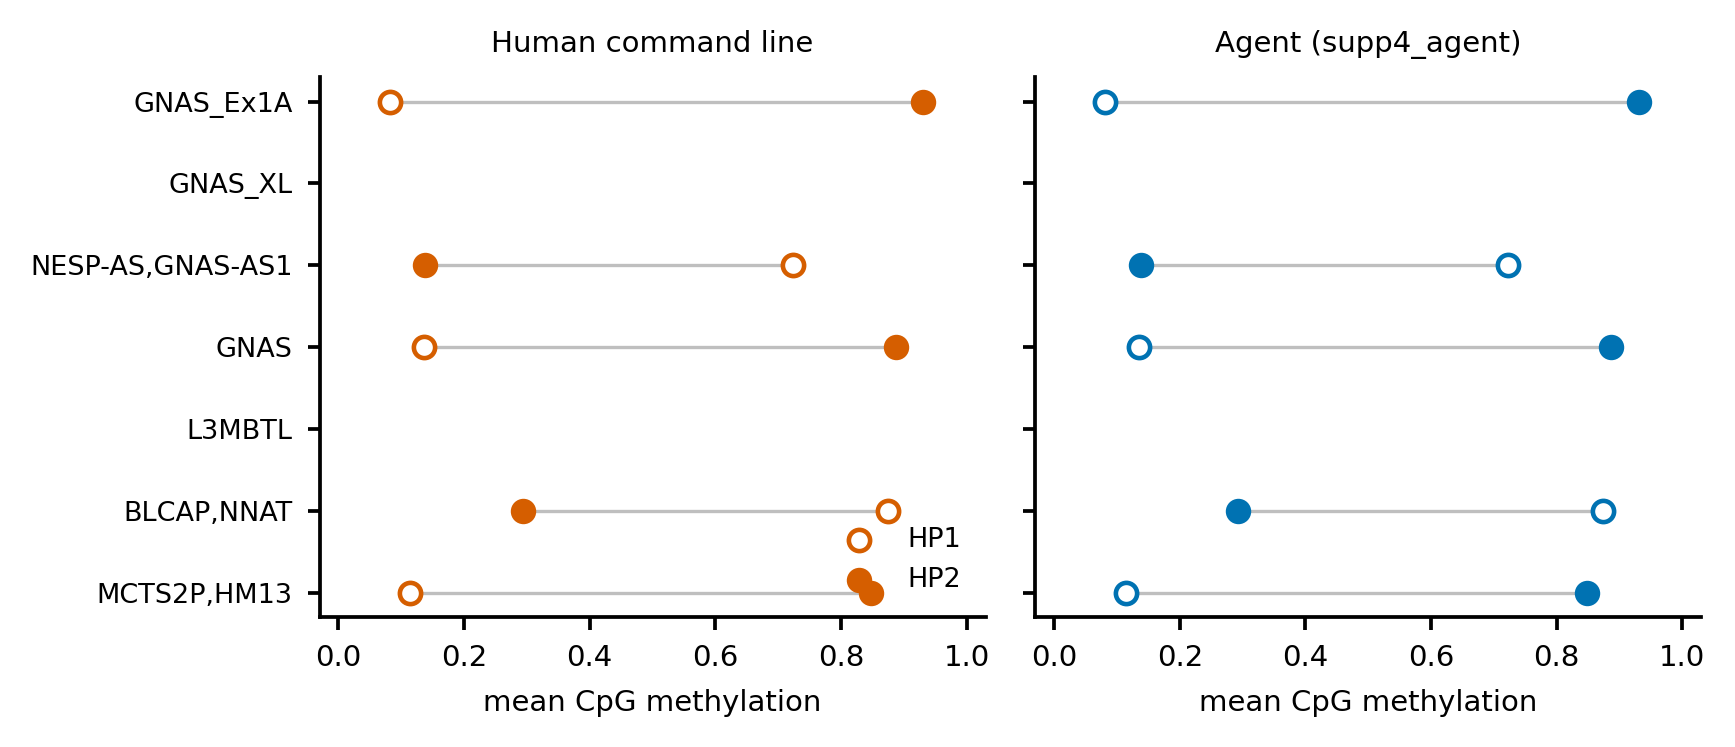

In [2]:
import os
os.environ["PANEL_PLATFORM"] = "PacBio"

# scripts/paper/make_panels.py, inlined. sys.argv is what the paper passes it.
import sys
sys.argv = ['make_panels.py', 'figure3', 'supp4_human', 'supp4_agent']
__file__ = "../scripts/paper/make_panels.py"

"""Draw the data panels of New Figure 2 and New Figure 3 from the evaluation records.

One plotting function per panel type serves every arm, so anything visible is a difference
in the data and not in the drawing. Human on the left, agent on the right, without
exception. Each panel is written as PDF and PNG, and the numbers behind it as CSV.

Usage: 50_make_panels.py figure2|figure3 <human_label> <agent_label> [more agent labels]
"""
from __future__ import annotations

import csv
import json
import sys
import os
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib import font_manager

sys.path.insert(0, str(Path(__file__).resolve().parent))
import panel_style

RUN = Path(os.environ.get("LV_RUN", "/project2/sli68423_1316/projects/long_verse/results/2026_09_25_longverse_agent_benchmark"))
EVAL = RUN / "evaluation"
FONT_DIR = Path(os.environ.get("LV_FONTS", "/project2/sli68423_1316/users/yang/software/fonts"))

FONT_USED = "DejaVu Sans"
for t in ("arial.ttf", "arialbd.ttf", "ariali.ttf"):
    if (FONT_DIR / t).is_file():
        font_manager.fontManager.addfont(str(FONT_DIR / t))
if (FONT_DIR / "arial.ttf").is_file():
    FONT_USED = "Arial"
panel_style.apply(plt, FONT_USED)
HUMAN_C, AGENT_C = "#D55E00", "#0072B2"
OTHER_C = ["#009E73", "#CC79A7", "#56B4E9"]


def load(label: str) -> dict:
    p = EVAL / f"{label}.json"
    if not p.is_file():
        raise SystemExit(f"missing evaluation record: {p}")
    return json.load(open(p))


def pearson(xs, ys):
    n = len(xs)
    mx, my = sum(xs) / n, sum(ys) / n
    sx = sum((v - mx) ** 2 for v in xs) ** 0.5
    sy = sum((v - my) ** 2 for v in ys) ** 0.5
    return (sum((xs[i] - mx) * (ys[i] - my) for i in range(n)) / (sx * sy)) if sx and sy else float("nan")


def prof(rec: dict) -> tuple[list, list]:
    m = rec["measurements"].get("tss_profile")
    if not m or not m.get("ok"):
        return [], []
    pts = m["payload"]["profile"]
    return [p["position_bp"] for p in pts], [p["mean_methylation"] for p in pts]


def draw_profile(ax, x, y, colour, title, compact: bool = False):
    """`compact` is for the single-arm panels, which are small and carry 12 pt type.

    Five tick labels and the words "mean CpG methylation" do not fit beside a 2.5 inch
    axis at 12 pt; three ticks and "CpG methylation" do. Nothing is shortened on the
    combined panel, which has the width for it.
    """
    ax.plot(x, y, color=colour, lw=2.0)
    ax.axvline(0, color="0.6", lw=0.8, ls="--")
    ax.set_xlim(min(x), max(x)); ax.set_ylim(0, 1)
    if compact:
        ax.set_xticks([-2000, 0, 2000])
        ax.set_xticklabels(["-2 kb", "TSS", "2 kb"])
        ax.set_yticks([0, 0.5, 1.0])
        ax.set_xlabel("distance to TSS"); ax.set_ylabel("CpG methylation")
    else:
        ax.set_xticks([-2000, -1000, 0, 1000, 2000])
        ax.set_xticklabels(["-2 kb", "-1 kb", "TSS", "1 kb", "2 kb"])
        ax.set_xlabel("distance to TSS"); ax.set_ylabel("mean CpG methylation")
    ax.set_title(title)


def panel_tss(out: Path, src: Path, human: dict, agents: list[dict]) -> dict:
    hx, hy = prof(human)
    if not hx:
        return {}
    cols = 1 + len(agents)
    fig, axes = plt.subplots(1, cols, figsize=(2.7 * cols, 2.3), sharey=True)
    axes = [axes] if cols == 1 else list(axes)
    draw_profile(axes[0], hx, hy, HUMAN_C, "Human command line")
    stats = {}
    for i, a in enumerate(agents):
        ax_, ay = prof(a)
        n = min(len(hy), len(ay))
        d = [ay[j] - hy[j] for j in range(n)]
        r = pearson(hy[:n], ay[:n])
        stats[a["arm"]] = {"n_bins": n, "pearson_r": round(r, 6),
                           "rms_difference": round((sum(v * v for v in d) / n) ** 0.5, 8),
                           "max_abs_difference": round(max(abs(v) for v in d), 8)}
        draw_profile(axes[i + 1], ax_, ay, AGENT_C if i == 0 else OTHER_C[i % 3],
                     f"Agent ({a['arm'].replace('agent_', '')})")
        axes[i + 1].set_ylabel("")
        axes[i + 1].text(0.97, 0.06,
                         f"r = {stats[a['arm']]['pearson_r']:.6f}\n"
                         f"RMS diff = {stats[a['arm']]['rms_difference']:.2e}",
                         transform=axes[i + 1].transAxes, ha="right", va="bottom", fontsize=6.5)
    fig.tight_layout()
    for e in ("pdf", "png"):
        fig.savefig(out / f"panel_tss_profile.{e}")
    plt.close(fig)

    # The same profiles again, one file per arm, so panel c can be laid out with the person
    # on the left and the agent on the right instead of as one strip. Same axes limits and
    # same drawing function, so a difference between the two files is a difference in data.
    for tag, xs, ys_, colour, title in (
            [("human", hx, hy, HUMAN_C, "TSS profile")]
            + [(f"agent", *prof(a), AGENT_C, "TSS profile") for a in agents[:1]]):
        f1, a1 = plt.subplots(figsize=(3.05, 2.95))
        draw_profile(a1, xs, ys_, colour, title, compact=True)
        f1.tight_layout()
        for e in ("pdf", "png"):
            f1.savefig(out / f"panel_tss_{tag}.{e}")
        plt.close(f1)
    with open(src / "panel_tss_profile.csv", "w", newline="") as fh:
        w = csv.writer(fh)
        w.writerow(["position_bp", "human"] + [a["arm"] for a in agents])
        series = [prof(a)[1] for a in agents]
        for j, x in enumerate(hx):
            w.writerow([x, f"{hy[j]:.6f}"] + [f"{s[j]:.6f}" if j < len(s) else "" for s in series])
    return stats


def panel_wgbs(out: Path, src: Path, human: dict, agents: list[dict]) -> dict:
    def rows(rec):
        m = rec["measurements"].get("wgbs_by_coverage")
        if not m or not m.get("ok"):
            return []
        return [r for r in m["payload"].get("results", []) if r.get("tool") == "ont"
                and r.get("PCC") is not None]
    hr = rows(human)
    if not hr:
        return {}
    fig, ax = plt.subplots(figsize=(3.1, 2.3))
    ax.plot([r["cov_bin_mid"] for r in hr], [r["PCC"] for r in hr], "o-",
            color=HUMAN_C, lw=1.4, ms=4, label="Human command line")
    stats = {}
    for i, a in enumerate(agents):
        ar = rows(a)
        if not ar:
            continue
        ax.plot([r["cov_bin_mid"] for r in ar], [r["PCC"] for r in ar], "s--",
                color=AGENT_C if i == 0 else OTHER_C[i % 3], lw=1.2, ms=3.5,
                label=f"Agent ({a['arm'].replace('agent_','')})")
        n = min(len(hr), len(ar))
        stats[a["arm"]] = {"bins": n,
                           "max_abs_PCC_difference": round(max(abs(ar[j]["PCC"] - hr[j]["PCC"])
                                                               for j in range(n)), 8)}
    ax.set_xlabel("ONT coverage bin (midpoint)"); ax.set_ylabel("Pearson r against WGBS")
    ax.set_ylim(0, 1); ax.legend(frameon=False, loc="lower right")
    ax.set_title("Agreement with WGBS by coverage")
    fig.tight_layout()
    for e in ("pdf", "png"):
        fig.savefig(out / f"panel_wgbs_by_coverage.{e}")
    plt.close(fig)

    # One file per arm, drawn at the width it is placed at, for the two-row panel c. The
    # axis label is shortened because at 12 pt "Pearson r against WGBS" is wider than the
    # 2.4 inch axis it labels; the caption says what the axis is.
    for tag, rec, colour, marker in (("human", human, HUMAN_C, "o-"),
                                     ("agent", agents[0] if agents else None, AGENT_C, "s-")):
        if rec is None:
            continue
        rr = rows(rec)
        if not rr:
            continue
        f1, a1 = plt.subplots(figsize=(3.05, 2.95))
        a1.plot([r["cov_bin_mid"] for r in rr], [r["PCC"] for r in rr], marker,
                color=colour, lw=2.0, ms=6)
        a1.set_xlabel("ONT coverage")
        a1.set_ylabel("r against WGBS")
        a1.set_ylim(0, 1)
        a1.set_yticks([0, 0.5, 1.0])
        a1.set_title("By coverage")
        f1.tight_layout()
        for e in ("pdf", "png"):
            f1.savefig(out / f"panel_wgbs_cov_{tag}.{e}")
        plt.close(f1)
    with open(src / "panel_wgbs_by_coverage.csv", "w", newline="") as fh:
        w = csv.writer(fh); w.writerow(["arm", "cov_bin", "cov_bin_mid", "n_cpg", "PCC", "MSE"])
        for lbl, rec in [("human", human)] + [(a["arm"], a) for a in agents]:
            for r in rows(rec):
                w.writerow([lbl, r["cov_bin"], r["cov_bin_mid"], r["n_cpg"], r["PCC"], r["MSE"]])
    return stats


def panel_icr(out: Path, src: Path, human: dict, agents: list[dict]) -> dict:
    def regions(rec):
        m = rec["measurements"].get("icr_haplotypes")
        if not m or not m.get("ok"):
            return {}
        return {r["name"]: (r["HP1_avg"], r["HP2_avg"], r["start"]) for r in m["payload"]["regions"]}
    hr = regions(human)
    if not hr:
        return {}
    order = sorted(hr, key=lambda k: int(hr[k][2]))
    cols = 1 + len(agents)
    fig, axes = plt.subplots(1, cols, figsize=(2.9 * cols, 2.5), sharey=True)
    axes = [axes] if cols == 1 else list(axes)
    stats = {}
    for i, (lbl, rec, colour) in enumerate(
            [("Human command line", human, HUMAN_C)] +
            [(f"Agent ({a['arm'].replace('agent_','')})", a,
              AGENT_C if k == 0 else OTHER_C[k % 3]) for k, a in enumerate(agents)]):
        rg = regions(rec)
        ax = axes[i]
        for j, n in enumerate(order):
            v = rg.get(n)
            if not v or v[0] is None or v[1] is None:
                continue
            ax.plot([v[0], v[1]], [j, j], color="0.75", lw=0.8, zorder=1)
            ax.scatter([v[0]], [j], s=26, facecolor="white", edgecolor=colour, lw=1.1, zorder=3)
            ax.scatter([v[1]], [j], s=26, color=colour, zorder=3)
        ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=6.5)
        ax.set_xlim(-0.03, 1.03); ax.set_xlabel("mean CpG methylation")
        ax.set_title(lbl); ax.invert_yaxis()
        if i:
            ax.set_ylabel("")
            pairs = [(hr[n][k], rg[n][k]) for n in order if n in rg
                     for k in (0, 1) if hr[n][k] is not None and rg[n][k] is not None]
            if pairs:
                stats[agents[i - 1]["arm"]] = {
                    "values": len(pairs),
                    "pearson_r": round(pearson([p[0] for p in pairs], [p[1] for p in pairs]), 6),
                    "max_abs_difference": round(max(abs(p[1] - p[0]) for p in pairs), 8)}
    axes[0].scatter([], [], s=26, facecolor="white", edgecolor=HUMAN_C, lw=1.1, label="HP1")
    axes[0].scatter([], [], s=26, color=HUMAN_C, label="HP2")
    axes[0].legend(loc="lower right", frameon=False, fontsize=6.5)
    fig.tight_layout()
    for e in ("pdf", "png"):
        fig.savefig(out / f"panel_icr_haplotype.{e}")
    plt.close(fig)
    with open(src / "panel_icr_haplotype.csv", "w", newline="") as fh:
        w = csv.writer(fh); w.writerow(["region", "arm", "HP1", "HP2"])
        for lbl, rec in [("human", human)] + [(a["arm"], a) for a in agents]:
            rg = regions(rec)
            for n in order:
                v = rg.get(n)
                if v:
                    w.writerow([n, lbl, v[0], v[1]])
    return stats


def main() -> int:
    if len(sys.argv) < 4:
        print(__doc__.strip().splitlines()[-1], file=sys.stderr)
        return 2
    which, hlabel, alabels = sys.argv[1], sys.argv[2], sys.argv[3:]
    out = RUN / which / "panels"; out.mkdir(parents=True, exist_ok=True)
    src = RUN / which / "source_data"; src.mkdir(parents=True, exist_ok=True)
    human = load(hlabel); agents = [load(a) for a in alabels]
    for r, lbl in [(human, hlabel)] + list(zip(agents, alabels)):
        r["arm"] = lbl
    summary = {"font_used": FONT_USED, "human": hlabel, "agents": alabels}
    if which == "figure2":
        summary["tss_profile"] = panel_tss(out, src, human, agents)
        summary["wgbs_by_coverage"] = panel_wgbs(out, src, human, agents)
    else:
        summary["icr_haplotype"] = panel_icr(out, src, human, agents)
    (RUN / which / "concordance.json").write_text(json.dumps(summary, indent=2))
    print(f"font: {FONT_USED}")
    print(json.dumps(summary, indent=2))
    print(f"panels -> {out}")
    return 0

main()
print(harvest('ed3'), "panels collected")
show("panel_icr_haplotype.png", prefix='ed3')

## a - what the agent consumed on this run

font: DejaVu Sans
  pacbio_phasing             $0.1038195  talk   0.4 min  compute   33.0 min  in    18 out   1121
panel -> ./data/runs/ed3_cost/panels/panel_agent_cost.png
2 panels collected


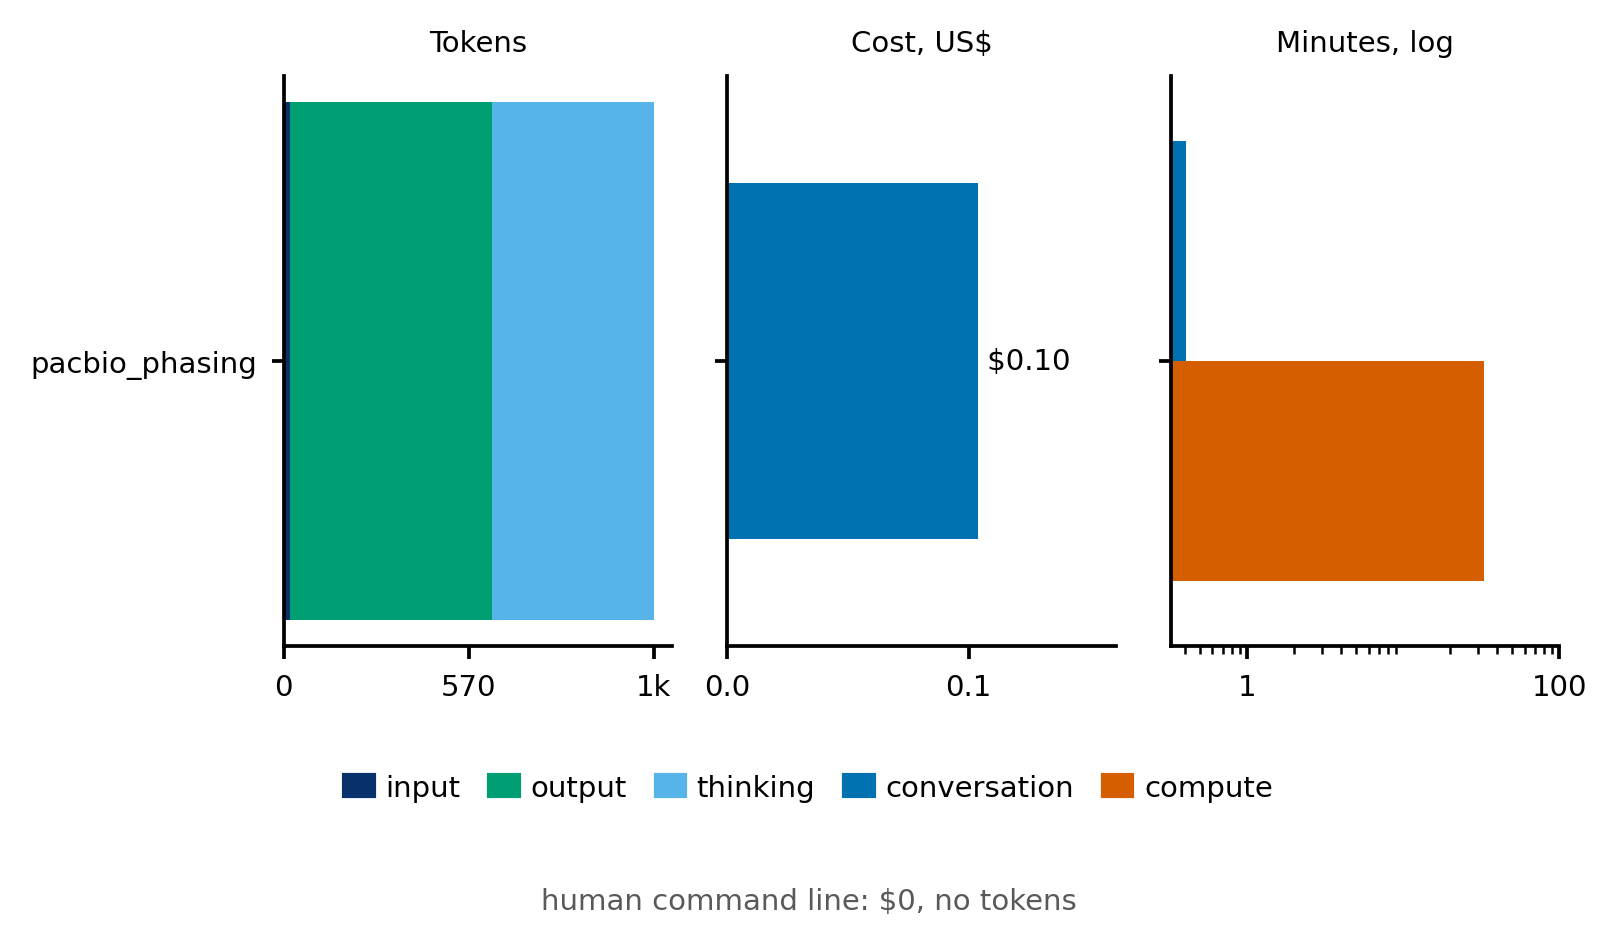

In [3]:
# scripts/paper/make_cost_panel.py, inlined. sys.argv is what the paper passes it.
import sys
sys.argv = ['make_cost_panel.py', 'ed3_cost', 'pacbio_phasing']
__file__ = "../scripts/paper/make_cost_panel.py"

"""The agent's cost, as a chart rather than a table.

Requirement R4: cost is drawn, not tabulated. Three things a reader needs, side by side:
where the tokens went, what each run cost, and how the conversation time compares with the
compute it set off. The last one is the point: a minute of talking buys hours of GPU.

Usage: 51_make_cost_panel.py <figure2|figure3> <run_id> [run_id ...]
       run ids are the keys in cost/agent_runs.csv
"""
from __future__ import annotations

import csv
import json
import sys
import os
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib import font_manager

sys.path.insert(0, str(Path(__file__).resolve().parent))
import panel_style

RUN = Path(os.environ.get("LV_RUN", "/project2/sli68423_1316/projects/long_verse/results/2026_09_25_longverse_agent_benchmark"))
FONT_DIR = Path(os.environ.get("LV_FONTS", "/project2/sli68423_1316/users/yang/software/fonts"))
FONT_USED = "DejaVu Sans"
for t in ("arial.ttf", "arialbd.ttf"):
    if (FONT_DIR / t).is_file():
        font_manager.fontManager.addfont(str(FONT_DIR / t))
if (FONT_DIR / "arial.ttf").is_file():
    FONT_USED = "Arial"
panel_style.apply(plt, FONT_USED)
# "input" and "conversation" shared one blue in a single legend, which reads as the same
# category listed twice; input is now a darker navy that no other series uses
C_IN, C_OUT, C_THINK, C_CACHE = "#08306B", "#009E73", "#56B4E9", "#BBBBBB"
AGENT_C, HUMAN_C = "#0072B2", "#D55E00"


def main() -> int:
    if len(sys.argv) < 3:
        print(__doc__.strip().splitlines()[-2], file=sys.stderr)
        return 2
    which, want = sys.argv[1], sys.argv[2:]
    rows = {r["run_id"]: r for r in csv.DictReader(open(RUN / "cost" / "agent_runs.csv"))}
    runs = [rows[w] for w in want if w in rows]
    if not runs:
        print(f"none of {want} in cost/agent_runs.csv; run 32_agent_cost_ledger.py first",
              file=sys.stderr)
        return 1
    out = RUN / which / "panels"; out.mkdir(parents=True, exist_ok=True)
    src = RUN / which / "source_data"; src.mkdir(parents=True, exist_ok=True)
    # "tools_only" on its own was read as the command line arm, which it is not: all three
    # of these are the agent, differing only in how much it is told. The human arm types a
    # command and spends no tokens at all, so it has no bar here and is stated instead.
    # Named for what the agent was given, not for the switch in the harness. "Paper2Agent
    # MCP" was considered and rejected: Paper2Agent is another group's system, and labelling
    # an arm with it invites the reader to think that system was run here. What was run is
    # this project's own MCP server; only the prompt layer follows the Paper2Agent design,
    # and that belongs in the text rather than on an axis.
    # Two arms, two labels, both short enough for an axis:
    #   MCP           this project's MCP server, tools attached and nothing else said
    #   Paper2Agent   the same server with its own prompt surfaced, which is the pattern
    #                 the Paper2Agent paper describes
    # The label names a design, not a piece of software that was executed here. Nothing of
    # Paper2Agent's own code was run, so the figure caption says so in words; putting that
    # qualification on the axis would make the axis unreadable.
    PRETTY = {
        "tools_only":  "MCP",
        "with_prompt": "MCP\n+ inspect hint",
        "mcp_prompt":  "Paper2Agent",
    }
    names = [PRETTY.get(r["run_id"].replace("upstream_", "").replace("phasing_", ""),
                        r["run_id"]) for r in runs]
    x = range(len(runs))

    # Drawn at the size it is placed at in the deck, 5.9 x 1.85 inches, rather than at a
    # comfortable size and shrunk afterwards. Shrinking a 7.4 inch figure into 3.9 inches
    # of slide scaled its 8 pt labels down to about 4 pt, which is where the tick labels
    # started running into the bars.
    # Horizontal bars, because at 12 pt the arm names will not fit under a vertical bar:
    # "MCP" and "Paper2Agent" collided into each other at every width tried. On the y axis
    # they have the whole row. Only the leftmost panel carries the names, the legend sits
    # below all three in one line, and the tick labels are shortened, because a 12 pt floor
    # in a 5.4 inch strip pays for itself in removed content, not in smaller type.
    fig, axes = plt.subplots(1, 3, figsize=(5.4, 2.45), sharey=True)
    yy = list(range(len(runs)))[::-1]

    def short(v):
        return f"{v/1000:.0f}k" if v >= 1000 else f"{v:.0f}"

    ax = axes[0]
    ins = [int(r["input_tokens"]) for r in runs]
    outs = [int(r["output_tokens"]) for r in runs]
    thinks = [int(r["thinking_tokens"]) for r in runs]
    vis = [o - t for o, t in zip(outs, thinks)]
    ax.barh(yy, ins, color=C_IN, label="input")
    ax.barh(yy, vis, left=ins, color=C_OUT, label="output")
    ax.barh(yy, thinks, left=[i + v for i, v in zip(ins, vis)], color=C_THINK,
            label="thinking")
    ax.set_yticks(yy); ax.set_yticklabels(names)
    ax.set_title("Tokens")
    hi = max(i + o for i, o in zip(ins, outs))
    ax.set_xticks([0, hi / 2, hi])
    ax.set_xticklabels(["0", short(hi / 2), short(hi)])

    ax = axes[1]
    costs = [float(r["cost_usd"]) for r in runs]
    ax.barh(yy, costs, color=AGENT_C, height=0.55)
    for y_, c in zip(yy, costs):
        ax.text(c, y_, f" ${c:.2f}", va="center", ha="left", fontsize=panel_style.MIN_PT)
    ax.set_title("Cost, US$")
    ax.set_xlim(0, max(costs) * 1.55)
    ax.set_xticks([0, round(max(costs), 1)])

    ax = axes[2]
    talk = [float(r["wall_seconds"]) / 60 for r in runs]
    meta = json.loads((RUN / which / "compute_minutes.json").read_text()) \
        if (RUN / which / "compute_minutes.json").is_file() else {}
    comp = [meta.get(r["run_id"], 0) for r in runs]
    h = 0.34
    ax.barh([y_ + h / 2 for y_ in yy], talk, height=h, color=AGENT_C, label="conversation")
    if any(comp):
        ax.barh([y_ - h / 2 for y_ in yy], comp, height=h, color=HUMAN_C, label="compute")
    ax.set_xscale("log")
    ax.set_title("Minutes, log")
    ax.set_xticks([1, 100])
    ax.set_xticklabels(["1", "100"])

    handles = [Patch(color=C_IN, label="input"), Patch(color=C_OUT, label="output"),
               Patch(color=C_THINK, label="thinking"),
               Patch(color=AGENT_C, label="conversation"), Patch(color=HUMAN_C, label="compute")]
    fig.legend(handles=handles, loc="lower center", ncol=5, frameon=False,
               fontsize=panel_style.MIN_PT, bbox_to_anchor=(0.5, -0.13),
               handlelength=1.0, handletextpad=0.4, columnspacing=1.0)
    fig.text(0.5, -0.24, "human command line: $0, no tokens", ha="center",
             fontsize=panel_style.MIN_PT, color="0.35")

    fig.tight_layout()
    for e in ("pdf", "png"):
        fig.savefig(out / f"panel_agent_cost.{e}")
    plt.close(fig)

    with open(src / "panel_agent_cost.csv", "w", newline="") as fh:
        w2 = csv.DictWriter(fh, fieldnames=list(runs[0]))
        w2.writeheader(); w2.writerows(runs)
    print(f"font: {FONT_USED}")
    for r, c in zip(runs, comp):
        print(f"  {r['run_id']:<26} ${r['cost_usd']:>7}  talk {float(r['wall_seconds'])/60:5.1f} min"
              f"  compute {c:6.1f} min  in {r['input_tokens']:>5} out {r['output_tokens']:>6}")
    print(f"panel -> {out/'panel_agent_cost.png'}")
    return 0

main()
print(harvest('ed3_cost'), "panels collected")
show("panel_agent_cost.png", prefix='ed3_cost')

## b - the imprinting control regions on chromosome 20, one plot per arm

Two per-region tables of 576 bytes, one from each arm's own phasing run.

  wrote panel_icr_human
  wrote panel_icr_agent
  7 regions, 2 without coverage
  wrote ./figures/notebook/panel_icr_by_region.pdf and ./figures/source_data/panel_icr_by_region.csv


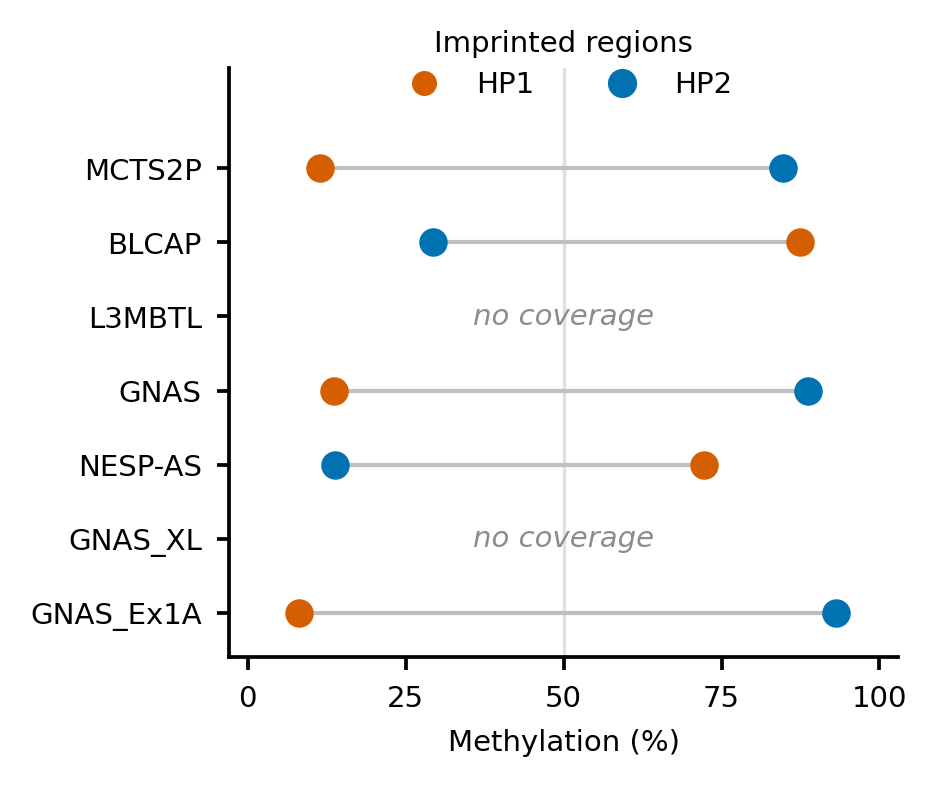

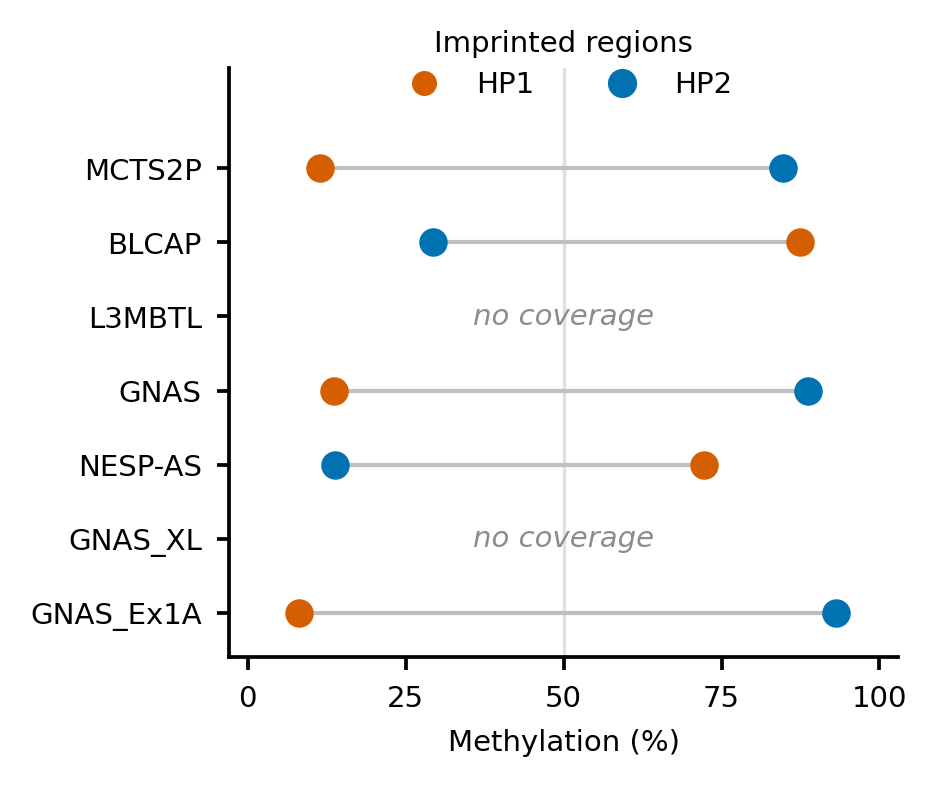

In [4]:
# scripts/paper/make_icr_panel.py, inlined. sys.argv is what the paper passes it.
import sys
sys.argv = ['make_icr_panel.py', f'{DATA}/ed_fig3/b_icr_human_phasing.csv', f'{DATA}/ed_fig3/b_icr_agent_phasing.csv', f'{OUT}']
__file__ = "../scripts/paper/make_icr_panel.py"

"""New Figure 3, the per-region panel: every imprinted control region on chromosome 20.

One row per region, the two haplotypes as a pair of points joined by a line. An imprinted
region should show one haplotype near fully methylated and the other near unmethylated; a
failed haplotype split shows both near the middle.

The two arms are drawn on the same axes rather than as two subplots. They produced
identical values, so side-by-side panels would be two copies of one picture; overlaying the
agent as open markers on the person's filled ones shows the agreement instead of asserting
it, and any disagreement would be visible as a marker that misses its point.

Usage: 57_make_icr_panel.py <human.csv> <agent.csv> <outdir>
"""
from __future__ import annotations

import csv
import sys
import os
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.lines import Line2D

sys.path.insert(0, str(Path(__file__).resolve().parent))
import panel_style

FONT_DIR = Path(os.environ.get("LV_FONTS", "/project2/sli68423_1316/users/yang/software/fonts"))
FONT_USED = "DejaVu Sans"
for t in ("arial.ttf", "arialbd.ttf", "ariali.ttf"):
    if (FONT_DIR / t).is_file():
        font_manager.fontManager.addfont(str(FONT_DIR / t))
if (FONT_DIR / "arial.ttf").is_file():
    FONT_USED = "Arial"
panel_style.apply(plt, FONT_USED)
HP1_C, HP2_C = "#D55E00", "#0072B2"


def short_name(name: str) -> str:
    """Region names that fit a 12 pt y axis on a 3.6 inch panel.

    The full names carry two gene symbols joined by a comma, which at 12 pt is wider than
    the plotting area it labels. The first symbol identifies the region unambiguously
    within chromosome 20 and the full names are in the source data CSV.
    """
    return name.split(",")[0].strip()


def load(path: Path) -> list[dict]:
    """Read the per-region CSV, keeping regions that actually have a value."""
    out = []
    with open(path, newline="") as fh:
        for r in csv.DictReader(fh):
            name = (r.get("Name") or "").strip().strip('"').replace("\t", ", ")
            try:
                hp1, hp2 = float(r["HP1_avg"]), float(r["HP2_avg"])
            except (TypeError, ValueError):
                out.append({"name": name, "hp1": None, "hp2": None,
                            "n1": r.get("HP1_ncpg"), "n2": r.get("HP2_ncpg")})
                continue
            out.append({"name": name, "hp1": hp1 * 100, "hp2": hp2 * 100,
                        "n1": r.get("HP1_ncpg"), "n2": r.get("HP2_ncpg")})
    return out


def main() -> int:
    if len(sys.argv) != 4:
        print(__doc__)
        return 2
    hp, ap, outdir = (Path(a) for a in sys.argv[1:4])
    outdir.mkdir(parents=True, exist_ok=True)
    human, agent = load(hp), load(ap)
    assert [r["name"] for r in human] == [r["name"] for r in agent], "region lists differ"

    fig, ax = plt.subplots(figsize=(9.6, 2.45))
    ys = list(range(len(human)))[::-1]
    n_missing = 0
    for y, h, a in zip(ys, human, agent):
        if h["hp1"] is None:
            n_missing += 1
            ax.text(50, y, "no CpG at coverage 5 or more", ha="center", va="center",
                    fontsize=6.5, color="0.55", style="italic")
            continue
        ax.plot([h["hp1"], h["hp2"]], [y, y], color="0.75", lw=1.0, zorder=1)
        ax.scatter([h["hp1"]], [y], s=42, color=HP1_C, zorder=3)
        ax.scatter([h["hp2"]], [y], s=42, color=HP2_C, zorder=3)
        # the agent's values, drawn on top; a mismatch would show as a ring off its dot
        ax.scatter([a["hp1"]], [y], s=90, facecolors="none", edgecolors=HP1_C,
                   lw=0.9, zorder=4)
        ax.scatter([a["hp2"]], [y], s=90, facecolors="none", edgecolors=HP2_C,
                   lw=0.9, zorder=4)
        ax.text(101.5, y, f"{h['n1']} / {h['n2']} CpG", ha="left", va="center",
                fontsize=6, color="0.45")

    ax.set_yticks(ys)
    ax.set_yticklabels([r["name"] for r in human], fontsize=7)
    ax.set_xlim(-3, 103)
    # headroom at the top for the legend, which used to sit below the axes and added
    # half an inch to a figure that is already tall
    ax.set_ylim(-0.6, len(human) + 0.35)
    ax.set_xticks([0, 25, 50, 75, 100])
    ax.set_xlabel("Average methylation in the region (%)")
    ax.axvline(50, color="0.88", lw=0.8, zorder=0)
    ax.set_title("Imprinted control regions on chromosome 20, by haplotype", pad=6)

    handles = [
        Line2D([], [], marker="o", ls="", color=HP1_C, markersize=6, label="HP1"),
        Line2D([], [], marker="o", ls="", color=HP2_C, markersize=6, label="HP2"),
        Line2D([], [], marker="o", ls="", markerfacecolor="none", markeredgecolor="0.3",
               markersize=9, label="agent (open), person (filled)"),
    ]
    ax.legend(handles=handles, frameon=False, loc="upper center",
              bbox_to_anchor=(0.5, 1.02), ncol=3, fontsize=6.5,
              handletextpad=0.4, columnspacing=1.6)

    for ext in ("pdf", "png"):
        fig.savefig(outdir / f"panel_icr_by_region.{ext}")
    plt.close(fig)

    # One plot per arm as well, so the deck can put the person on the left and the agent on
    # the right. Drawn on the same x axis and the same row order, so a difference between
    # the two sides would be a difference in the data.
    for tag, rowset in (("human", human), ("agent", agent)):
        f1, a1 = plt.subplots(figsize=(2.88, 2.55))
        for y, r in zip(ys, rowset):
            if r["hp1"] is None:
                a1.text(50, y, "no coverage", ha="center", va="center",
                        color="0.55", style="italic")
                continue
            a1.plot([r["hp1"], r["hp2"]], [y, y], color="0.75", lw=1.0, zorder=1)
            a1.scatter([r["hp1"]], [y], s=34, color=HP1_C, zorder=3)
            a1.scatter([r["hp2"]], [y], s=34, color=HP2_C, zorder=3)
        a1.set_yticks(ys)
        a1.set_yticklabels([short_name(r["name"]) for r in rowset])
        a1.set_xlim(-3, 103)
        a1.set_ylim(-0.6, len(rowset) + 0.35)
        a1.set_xticks([0, 25, 50, 75, 100])
        a1.set_xlabel("Methylation (%)")
        a1.axvline(50, color="0.88", lw=0.8, zorder=0)
        a1.set_title("Imprinted regions", pad=4)
        a1.legend(handles=[
            Line2D([], [], marker="o", ls="", color=HP1_C, markersize=5, label="HP1"),
            Line2D([], [], marker="o", ls="", color=HP2_C, markersize=6, label="HP2")],
            frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.04), ncol=2)
        for ext in ("pdf", "png"):
            f1.savefig(outdir / f"panel_icr_{tag}.{ext}")
        plt.close(f1)
        print(f"  wrote panel_icr_{tag}")

    csv_out = outdir.parent / "source_data" / "panel_icr_by_region.csv"
    csv_out.parent.mkdir(parents=True, exist_ok=True)
    with open(csv_out, "w", newline="") as fh:
        w = csv.writer(fh)
        w.writerow(["region", "human_HP1_pct", "human_HP2_pct", "agent_HP1_pct",
                    "agent_HP2_pct", "HP1_ncpg", "HP2_ncpg", "identical"])
        for h, a in zip(human, agent):
            same = (h["hp1"] == a["hp1"] and h["hp2"] == a["hp2"])
            w.writerow([h["name"], h["hp1"], h["hp2"], a["hp1"], a["hp2"],
                        h["n1"], h["n2"], same])
    print(f"  {len(human)} regions, {n_missing} without coverage")
    print(f"  wrote {outdir / 'panel_icr_by_region.pdf'} and {csv_out}")
    return 0

main()
show("panel_icr_human.png", "panel_icr_agent.png")

## b - GNAS per haplotype, the expert's run

In [5]:
%%R
## scripts/paper/modbam_region_plot.R, run as R. Edit any line and re-run the cell.

#!/usr/bin/env Rscript
rm(list = ls())

library(argparser)
library(NanoMethViz)
library(dplyr)
library(rtracklayer)
library(GenomicRanges)

# ---------------------------------------------------------------------------
# NanoMethViz region plot for two ModBAM files (HP1 vs HP2) on T2T (hs1) coords
#
# Example:
# Rscript modbam_nanomethviz_hp_region_plot.R \
#   --hp1_bam /path/to/HP1.bam \
#   --hp2_bam /path/to/HP2.bam \
#   --chr chr11 --start 118453794 --end 118548121 \
#   --flank 5000 --tagname KMT2A --svg
# ---------------------------------------------------------------------------
parser <- arg_parser(
	"Plot NanoMethViz methylation tracks at a user-defined region from two ModBAM files (HP1, HP2)."
)

parser <- add_argument(parser, "--hp1_bam", help = "HP1 ModBAM file path", type = "character")
parser <- add_argument(parser, "--hp2_bam", help = "HP2 ModBAM file path", type = "character")
parser <- add_argument(parser, "--hp1_name", help = "HP1 sample name in plot", type = "character", default = "HP1")
parser <- add_argument(parser, "--hp2_name", help = "HP2 sample name in plot", type = "character", default = "HP2")
parser <- add_argument(parser, "--chr", help = "Chromosome (T2T, e.g. chr11)", type = "character")
parser <- add_argument(parser, "--start", help = "Region start coordinate", type = "integer")
parser <- add_argument(parser, "--end", help = "Region end coordinate", type = "integer")
parser <- add_argument(parser, "--flank", help = "Flanking bp added to start/end", type = "integer", default = 2000)
parser <- add_argument(
	parser, "--gtf_file", help = "T2T GTF annotation file (hs1.ncbiRefSeq.gtf)",
	type = "character",
	default = "/project2/sli68423_1316/users/yang/reference/chm13v2.0/genes/hs1.ncbiRefSeq.gtf"
)
parser <- add_argument(parser, "--wdir", help = "Working directory", type = "character", default = ".")
parser <- add_argument(parser, "--outdir", help = "Output directory for plots", type = "character", default = "modbam_plots")
parser <- add_argument(parser, "--outfn_prefix", help = "Output file name prefix", type = "character", default = "nanomethviz_hp_region")
parser <- add_argument(parser, "--tagname", help = "Tag appended to output file name", type = "character", default = "")
parser <- add_argument(parser, "--fig_w", help = "Figure width (inches)", type = "integer", default = 8)
parser <- add_argument(parser, "--fig_h", help = "Figure height (inches)", type = "integer", default = 7)
parser <- add_argument(parser, "--avg_method", help = "Aggregation method: mean or median", type = "character", default = "mean")
parser <- add_argument(parser, "--smoothing_window", help = "Smoothing window (bp)", type = "integer", default = 2000)
parser <- add_argument(parser, "--heatmap_subsample", help = "Heatmap subsample size", type = "integer", default = 200)
parser <- add_argument(parser, "--hp1_color", help = "HP1 track color", type = "character", default = "#E41A1C")
parser <- add_argument(parser, "--hp2_color", help = "HP2 track color", type = "character", default = "#377EB8")
parser <- add_argument(parser, "--svg", help = "Also save SVG output", flag = TRUE)
parser <- add_argument(parser, "--png", help = "Also save PNG output", flag = TRUE)
parser <- add_argument(parser, "--png_dpi", help = "PNG resolution (dpi)", type = "integer", default = 600)
parser <- add_argument(parser, "--no_gene_anno", help = "Hide gene annotation track", flag = TRUE)

## parse_args given its arguments directly; a notebook has no command line.
args <- parse_args(parser, c("--hp1_bam", file.path(Sys.getenv("LV_DATA"), "gnas_arms/ed3b_pacbio_human_HP1.bam"), "--hp2_bam", file.path(Sys.getenv("LV_DATA"), "gnas_arms/ed3b_pacbio_human_HP2.bam"), "--chr", "chr20", "--start", "60622123", "--end", "60626697", "--flank", "3000", "--gtf_file", file.path(Sys.getenv("LV_DATA"), "icr_bam/hs1.ncbiRefSeq.icr.gtf"), "--outdir", Sys.getenv("LV_OUT"), "--outfn_prefix", "ed3b_human", "--tagname", "GNAS", "--fig_w", "7", "--fig_h", "6", "--png"))
str(args)

if (args$start >= args$end) {
	stop("--start must be less than --end")
}

required_files <- c(args$hp1_bam, args$hp2_bam, args$gtf_file)
missing_files <- required_files[!file.exists(required_files)]
if (length(missing_files) > 0) {
	stop("Missing input file(s):\n", paste(missing_files, collapse = "\n"))
}

if (!dir.exists(args$wdir)) {
	stop("wdir not found: ", args$wdir)
}
setwd(args$wdir)

outdir <- args$outdir
if (!dir.exists(outdir)) {
	dir.create(outdir, recursive = TRUE, showWarnings = FALSE)
}

# ---------------------------------------------------------------------------
# T2T exon annotation (shared style with prior NanoMethViz scripts)
# ---------------------------------------------------------------------------
get_all_exon <- function(gtf_df) {
	exon_df <- gtf_df[gtf_df$type == "exon", ]
	exon_table <- exon_df %>%
		dplyr::select(
			gene_id = gene_id,
			chr = seqnames,
			strand = strand,
			start = start,
			end = end,
			transcript_id = transcript_id,
			symbol = gene_name
		)
	tibble::as_tibble(exon_table)
}

get_region_exons <- function(exon_tibble, chr, region_start, region_end) {
	region_gr <- GRanges(
		seqnames = chr,
		ranges = IRanges(start = region_start, end = region_end)
	)
	exon_gr <- GRanges(
		seqnames = exon_tibble$chr,
		ranges = IRanges(start = exon_tibble$start, end = exon_tibble$end)
	)
	hits <- findOverlaps(exon_gr, region_gr)
	tibble::as_tibble(exon_tibble[queryHits(hits), , drop = FALSE])
}

gtf_data <- import(args$gtf_file)
gtf_df <- as.data.frame(gtf_data)

region_start <- max(1L, args$start - args$flank)
region_end <- args$end + args$flank
exon_tibble <- get_region_exons(
	get_all_exon(gtf_df),
	chr = args$chr,
	region_start = region_start,
	region_end = region_end
)

if (nrow(exon_tibble) == 0) {
	warning("No exons overlap region ", args$chr, ":", region_start, "-", region_end)
}

# ---------------------------------------------------------------------------
# Build ModBAM NanoMethViz object (HP1 vs HP2)
# ---------------------------------------------------------------------------
sample_names <- c(args$hp1_name, args$hp2_name)
bam_files <- c(args$hp1_bam, args$hp2_bam)
group_names <- sample_names

mbr <- ModBamResult(
	methy = ModBamFiles(
		samples = sample_names,
		bam_files
	),
	samples = data.frame(
		sample = sample_names,
		group = group_names,
		stringsAsFactors = FALSE
	),
	exons = exon_tibble
)

grange <- GRanges(
	seqnames = args$chr,
	ranges = IRanges(start = region_start, end = region_end)
)

palette1 <- ggplot2::scale_colour_manual(
	values = stats::setNames(c(args$hp1_color, args$hp2_color), sample_names)
)

show_gene_anno <- !args$no_gene_anno

np1 <- plot_grange(
	mbr,
	grange,
	palette = palette1,
	avg_method = args$avg_method,
	smoothing_window = args$smoothing_window,
	heatmap_subsample = args$heatmap_subsample,
	gene_anno = show_gene_anno
)

# ---------------------------------------------------------------------------
# Save outputs
# ---------------------------------------------------------------------------
if (nzchar(args$tagname)) {
	out_prefix <- sprintf("%s_%s", args$outfn_prefix, args$tagname)
} else {
	out_prefix <- sprintf(
		"%s_%s_%d_%d",
		args$outfn_prefix,
		gsub("^chr", "", args$chr),
		args$start,
		args$end
	)
}

save_plot <- function(device_fn, width, height, ...) {
	graphics.off()
	device_fn(file.path(outdir, outfn), width = width, height = height, ...)
	print(np1)
	dev.off()
}

outfn <- sprintf("%s.pdf", out_prefix)
save_plot(pdf, args$fig_w, args$fig_h)
cat("Saved to", file.path(outdir, outfn), "\n")

if (args$svg) {
	outfn <- sprintf("%s.svg", out_prefix)
	save_plot(svg, args$fig_w, args$fig_h)
	cat("Saved to", file.path(outdir, outfn), "\n")
}

if (args$png) {
	outfn <- sprintf("%s.png", out_prefix)
	save_plot(
		png,
		args$fig_w,
		args$fig_h,
		units = "in",
		res = args$png_dpi
	)
	cat("Saved to", file.path(outdir, outfn), "\n")
}

rdata_fn <- file.path(outdir, sprintf("%s.RData", out_prefix))
save.image(rdata_fn)
cat("Saved workspace to", rdata_fn, "\n")

cat("### Done\n")

## The magic closes a device when the cell ends, and the script's
## graphics.off() already closed it. Give it one to close.
grDevices::pdf(NULL)


List

 of 

27

$ 

:

...

./figures/notebook/ed3b_human_GNAS.png

Saved workspace to

./figures/notebook/ed3b_human_GNAS.RData

### Done


Loading required package: ggplot2
Posit Community (formerly RStudio Community) is a great place to get
help: https://forum.posit.co/c/tidyverse

Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

Loading required package: GenomicRanges
Loading required package: stats4
Loading required package: BiocGenerics

Attaching package: ‘BiocGenerics’

The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union

The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs

The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Po

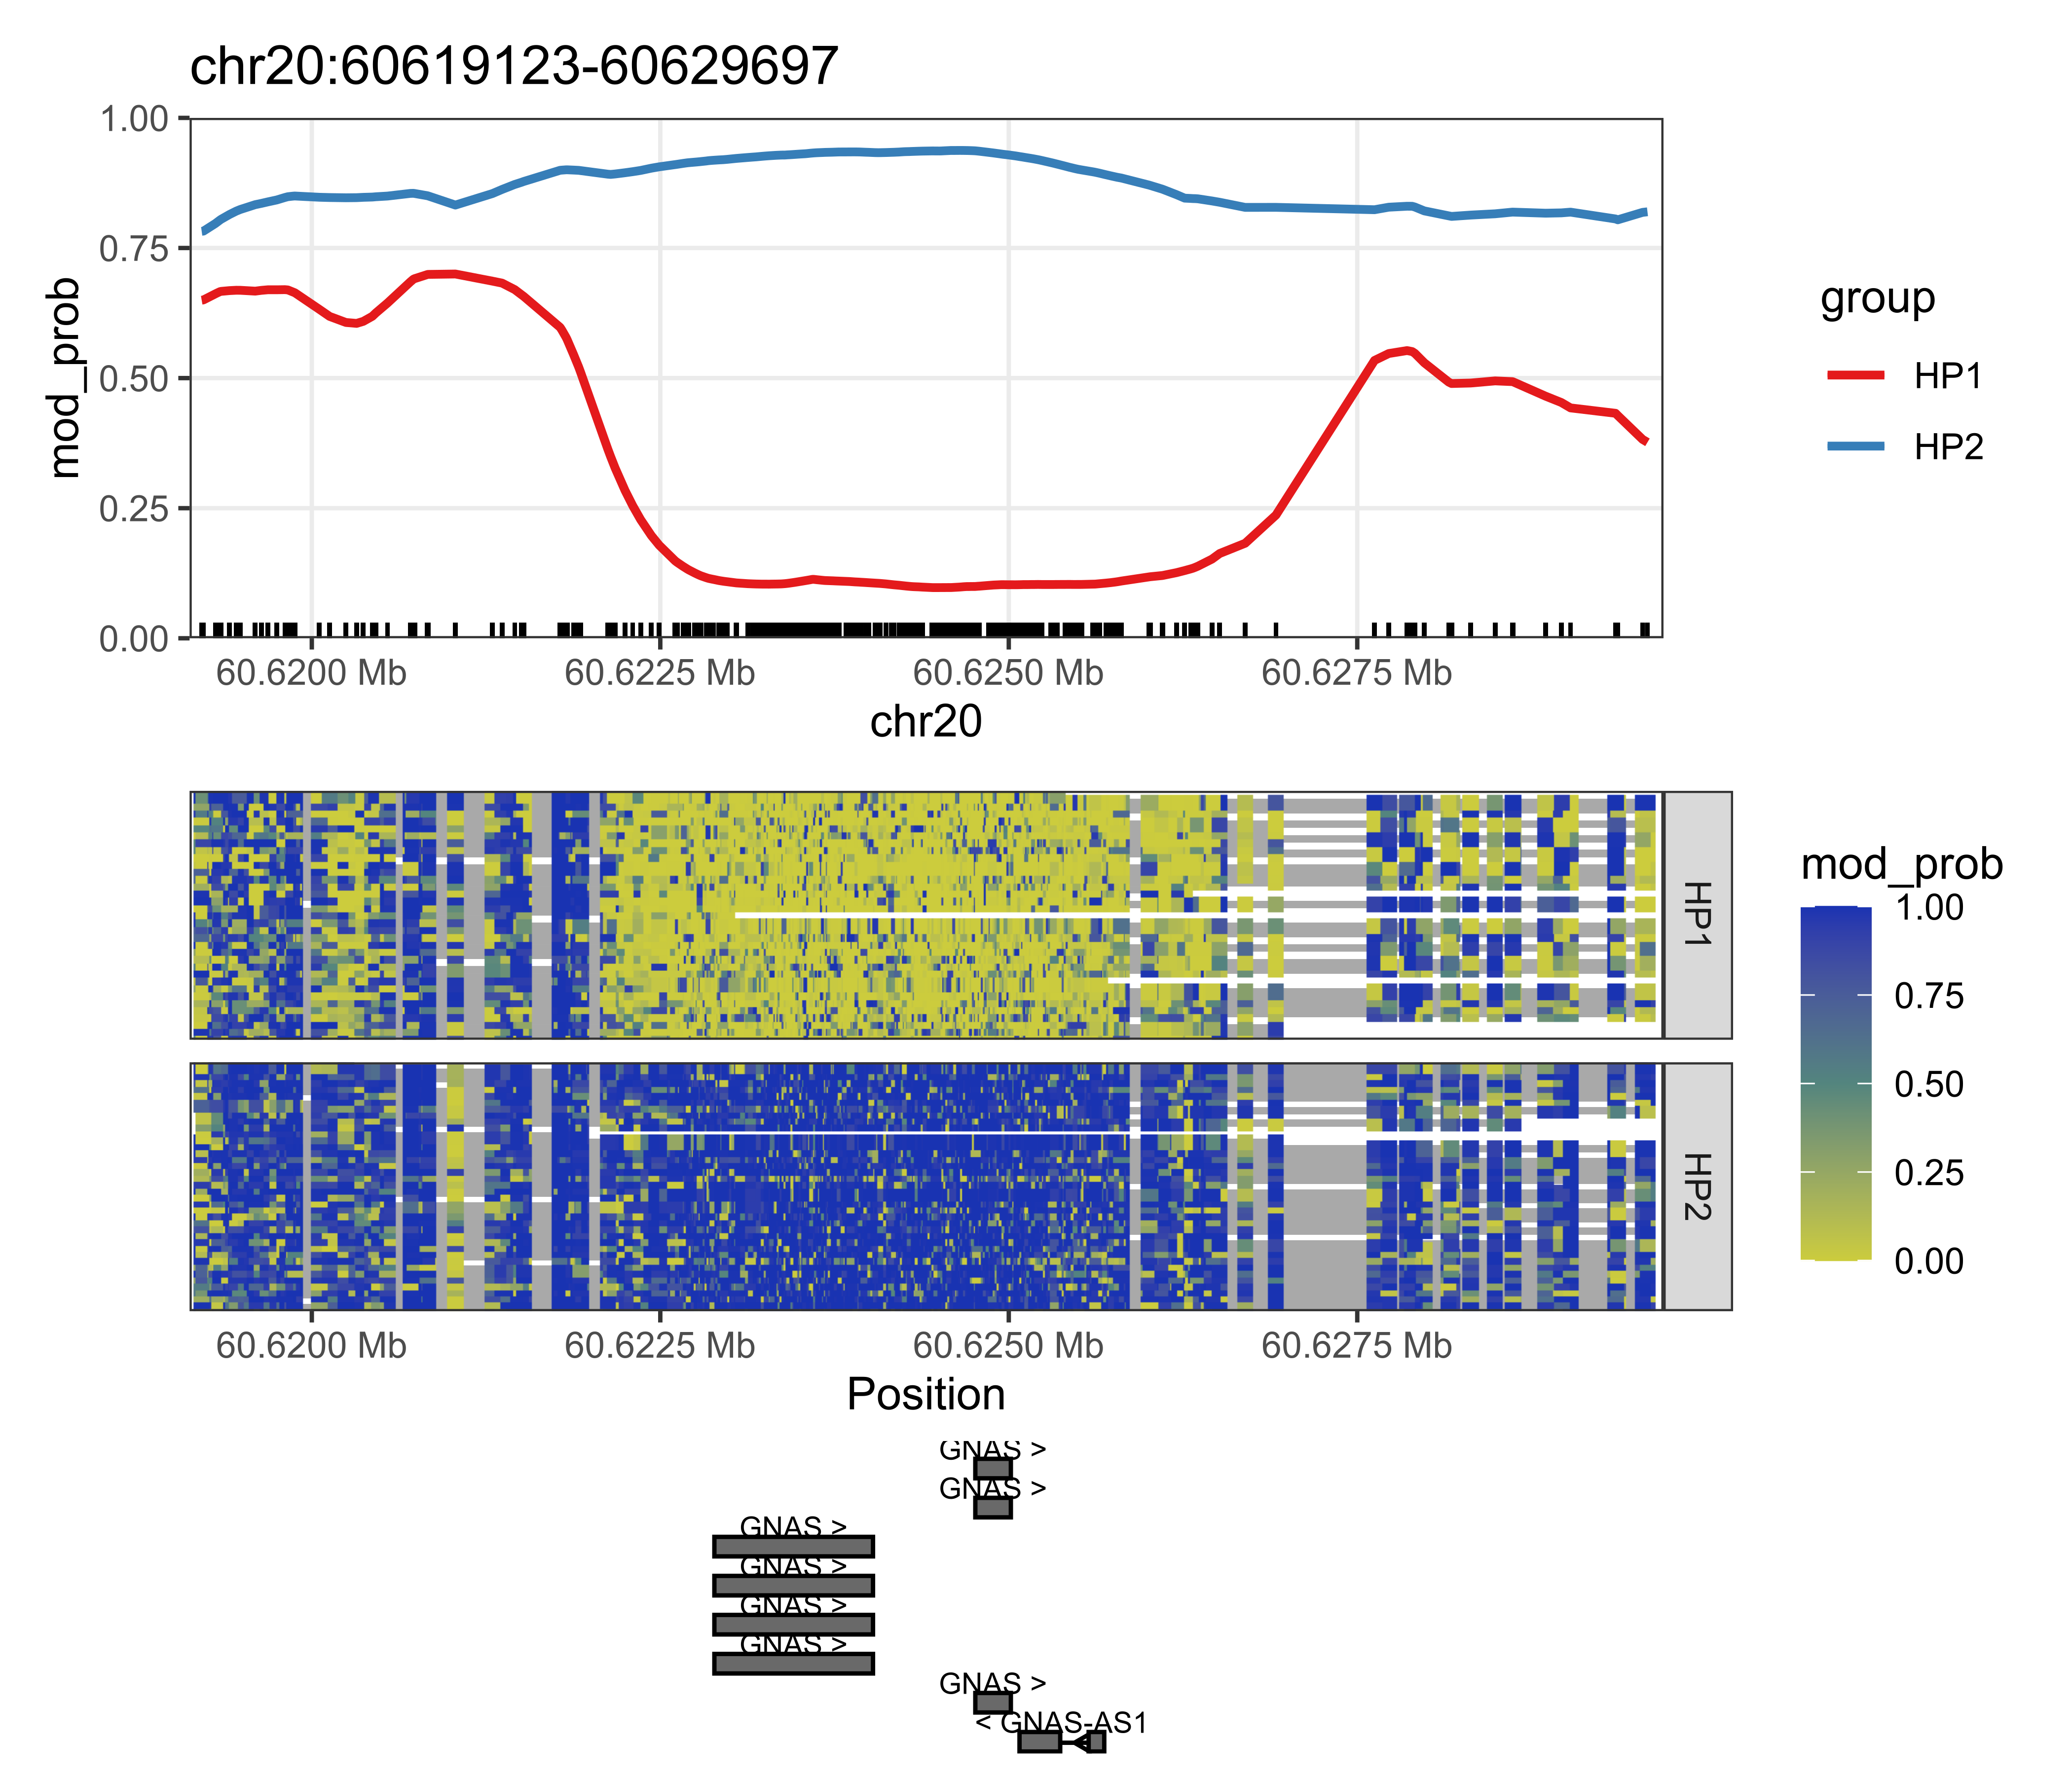

In [6]:
show('ed3b_human_GNAS.png')

## b - the same window, the agent's run

In [7]:
%%R
## scripts/paper/modbam_region_plot.R, run as R. Edit any line and re-run the cell.

#!/usr/bin/env Rscript
rm(list = ls())

library(argparser)
library(NanoMethViz)
library(dplyr)
library(rtracklayer)
library(GenomicRanges)

# ---------------------------------------------------------------------------
# NanoMethViz region plot for two ModBAM files (HP1 vs HP2) on T2T (hs1) coords
#
# Example:
# Rscript modbam_nanomethviz_hp_region_plot.R \
#   --hp1_bam /path/to/HP1.bam \
#   --hp2_bam /path/to/HP2.bam \
#   --chr chr11 --start 118453794 --end 118548121 \
#   --flank 5000 --tagname KMT2A --svg
# ---------------------------------------------------------------------------
parser <- arg_parser(
	"Plot NanoMethViz methylation tracks at a user-defined region from two ModBAM files (HP1, HP2)."
)

parser <- add_argument(parser, "--hp1_bam", help = "HP1 ModBAM file path", type = "character")
parser <- add_argument(parser, "--hp2_bam", help = "HP2 ModBAM file path", type = "character")
parser <- add_argument(parser, "--hp1_name", help = "HP1 sample name in plot", type = "character", default = "HP1")
parser <- add_argument(parser, "--hp2_name", help = "HP2 sample name in plot", type = "character", default = "HP2")
parser <- add_argument(parser, "--chr", help = "Chromosome (T2T, e.g. chr11)", type = "character")
parser <- add_argument(parser, "--start", help = "Region start coordinate", type = "integer")
parser <- add_argument(parser, "--end", help = "Region end coordinate", type = "integer")
parser <- add_argument(parser, "--flank", help = "Flanking bp added to start/end", type = "integer", default = 2000)
parser <- add_argument(
	parser, "--gtf_file", help = "T2T GTF annotation file (hs1.ncbiRefSeq.gtf)",
	type = "character",
	default = "/project2/sli68423_1316/users/yang/reference/chm13v2.0/genes/hs1.ncbiRefSeq.gtf"
)
parser <- add_argument(parser, "--wdir", help = "Working directory", type = "character", default = ".")
parser <- add_argument(parser, "--outdir", help = "Output directory for plots", type = "character", default = "modbam_plots")
parser <- add_argument(parser, "--outfn_prefix", help = "Output file name prefix", type = "character", default = "nanomethviz_hp_region")
parser <- add_argument(parser, "--tagname", help = "Tag appended to output file name", type = "character", default = "")
parser <- add_argument(parser, "--fig_w", help = "Figure width (inches)", type = "integer", default = 8)
parser <- add_argument(parser, "--fig_h", help = "Figure height (inches)", type = "integer", default = 7)
parser <- add_argument(parser, "--avg_method", help = "Aggregation method: mean or median", type = "character", default = "mean")
parser <- add_argument(parser, "--smoothing_window", help = "Smoothing window (bp)", type = "integer", default = 2000)
parser <- add_argument(parser, "--heatmap_subsample", help = "Heatmap subsample size", type = "integer", default = 200)
parser <- add_argument(parser, "--hp1_color", help = "HP1 track color", type = "character", default = "#E41A1C")
parser <- add_argument(parser, "--hp2_color", help = "HP2 track color", type = "character", default = "#377EB8")
parser <- add_argument(parser, "--svg", help = "Also save SVG output", flag = TRUE)
parser <- add_argument(parser, "--png", help = "Also save PNG output", flag = TRUE)
parser <- add_argument(parser, "--png_dpi", help = "PNG resolution (dpi)", type = "integer", default = 600)
parser <- add_argument(parser, "--no_gene_anno", help = "Hide gene annotation track", flag = TRUE)

## parse_args given its arguments directly; a notebook has no command line.
args <- parse_args(parser, c("--hp1_bam", file.path(Sys.getenv("LV_DATA"), "gnas_arms/ed3b_pacbio_agent_HP1.bam"), "--hp2_bam", file.path(Sys.getenv("LV_DATA"), "gnas_arms/ed3b_pacbio_agent_HP2.bam"), "--chr", "chr20", "--start", "60622123", "--end", "60626697", "--flank", "3000", "--gtf_file", file.path(Sys.getenv("LV_DATA"), "icr_bam/hs1.ncbiRefSeq.icr.gtf"), "--outdir", Sys.getenv("LV_OUT"), "--outfn_prefix", "ed3b_agent", "--tagname", "GNAS", "--fig_w", "7", "--fig_h", "6", "--png"))
str(args)

if (args$start >= args$end) {
	stop("--start must be less than --end")
}

required_files <- c(args$hp1_bam, args$hp2_bam, args$gtf_file)
missing_files <- required_files[!file.exists(required_files)]
if (length(missing_files) > 0) {
	stop("Missing input file(s):\n", paste(missing_files, collapse = "\n"))
}

if (!dir.exists(args$wdir)) {
	stop("wdir not found: ", args$wdir)
}
setwd(args$wdir)

outdir <- args$outdir
if (!dir.exists(outdir)) {
	dir.create(outdir, recursive = TRUE, showWarnings = FALSE)
}

# ---------------------------------------------------------------------------
# T2T exon annotation (shared style with prior NanoMethViz scripts)
# ---------------------------------------------------------------------------
get_all_exon <- function(gtf_df) {
	exon_df <- gtf_df[gtf_df$type == "exon", ]
	exon_table <- exon_df %>%
		dplyr::select(
			gene_id = gene_id,
			chr = seqnames,
			strand = strand,
			start = start,
			end = end,
			transcript_id = transcript_id,
			symbol = gene_name
		)
	tibble::as_tibble(exon_table)
}

get_region_exons <- function(exon_tibble, chr, region_start, region_end) {
	region_gr <- GRanges(
		seqnames = chr,
		ranges = IRanges(start = region_start, end = region_end)
	)
	exon_gr <- GRanges(
		seqnames = exon_tibble$chr,
		ranges = IRanges(start = exon_tibble$start, end = exon_tibble$end)
	)
	hits <- findOverlaps(exon_gr, region_gr)
	tibble::as_tibble(exon_tibble[queryHits(hits), , drop = FALSE])
}

gtf_data <- import(args$gtf_file)
gtf_df <- as.data.frame(gtf_data)

region_start <- max(1L, args$start - args$flank)
region_end <- args$end + args$flank
exon_tibble <- get_region_exons(
	get_all_exon(gtf_df),
	chr = args$chr,
	region_start = region_start,
	region_end = region_end
)

if (nrow(exon_tibble) == 0) {
	warning("No exons overlap region ", args$chr, ":", region_start, "-", region_end)
}

# ---------------------------------------------------------------------------
# Build ModBAM NanoMethViz object (HP1 vs HP2)
# ---------------------------------------------------------------------------
sample_names <- c(args$hp1_name, args$hp2_name)
bam_files <- c(args$hp1_bam, args$hp2_bam)
group_names <- sample_names

mbr <- ModBamResult(
	methy = ModBamFiles(
		samples = sample_names,
		bam_files
	),
	samples = data.frame(
		sample = sample_names,
		group = group_names,
		stringsAsFactors = FALSE
	),
	exons = exon_tibble
)

grange <- GRanges(
	seqnames = args$chr,
	ranges = IRanges(start = region_start, end = region_end)
)

palette1 <- ggplot2::scale_colour_manual(
	values = stats::setNames(c(args$hp1_color, args$hp2_color), sample_names)
)

show_gene_anno <- !args$no_gene_anno

np1 <- plot_grange(
	mbr,
	grange,
	palette = palette1,
	avg_method = args$avg_method,
	smoothing_window = args$smoothing_window,
	heatmap_subsample = args$heatmap_subsample,
	gene_anno = show_gene_anno
)

# ---------------------------------------------------------------------------
# Save outputs
# ---------------------------------------------------------------------------
if (nzchar(args$tagname)) {
	out_prefix <- sprintf("%s_%s", args$outfn_prefix, args$tagname)
} else {
	out_prefix <- sprintf(
		"%s_%s_%d_%d",
		args$outfn_prefix,
		gsub("^chr", "", args$chr),
		args$start,
		args$end
	)
}

save_plot <- function(device_fn, width, height, ...) {
	graphics.off()
	device_fn(file.path(outdir, outfn), width = width, height = height, ...)
	print(np1)
	dev.off()
}

outfn <- sprintf("%s.pdf", out_prefix)
save_plot(pdf, args$fig_w, args$fig_h)
cat("Saved to", file.path(outdir, outfn), "\n")

if (args$svg) {
	outfn <- sprintf("%s.svg", out_prefix)
	save_plot(svg, args$fig_w, args$fig_h)
	cat("Saved to", file.path(outdir, outfn), "\n")
}

if (args$png) {
	outfn <- sprintf("%s.png", out_prefix)
	save_plot(
		png,
		args$fig_w,
		args$fig_h,
		units = "in",
		res = args$png_dpi
	)
	cat("Saved to", file.path(outdir, outfn), "\n")
}

rdata_fn <- file.path(outdir, sprintf("%s.RData", out_prefix))
save.image(rdata_fn)
cat("Saved workspace to", rdata_fn, "\n")

cat("### Done\n")

## The magic closes a device when the cell ends, and the script's
## graphics.off() already closed it. Give it one to close.
grDevices::pdf(NULL)


List

 of 

27

$ 

:

...

Saved to

./figures/notebook/ed3b_agent_GNAS.png

Saved workspace to

./figures/notebook/ed3b_agent_GNAS.RData

### Done


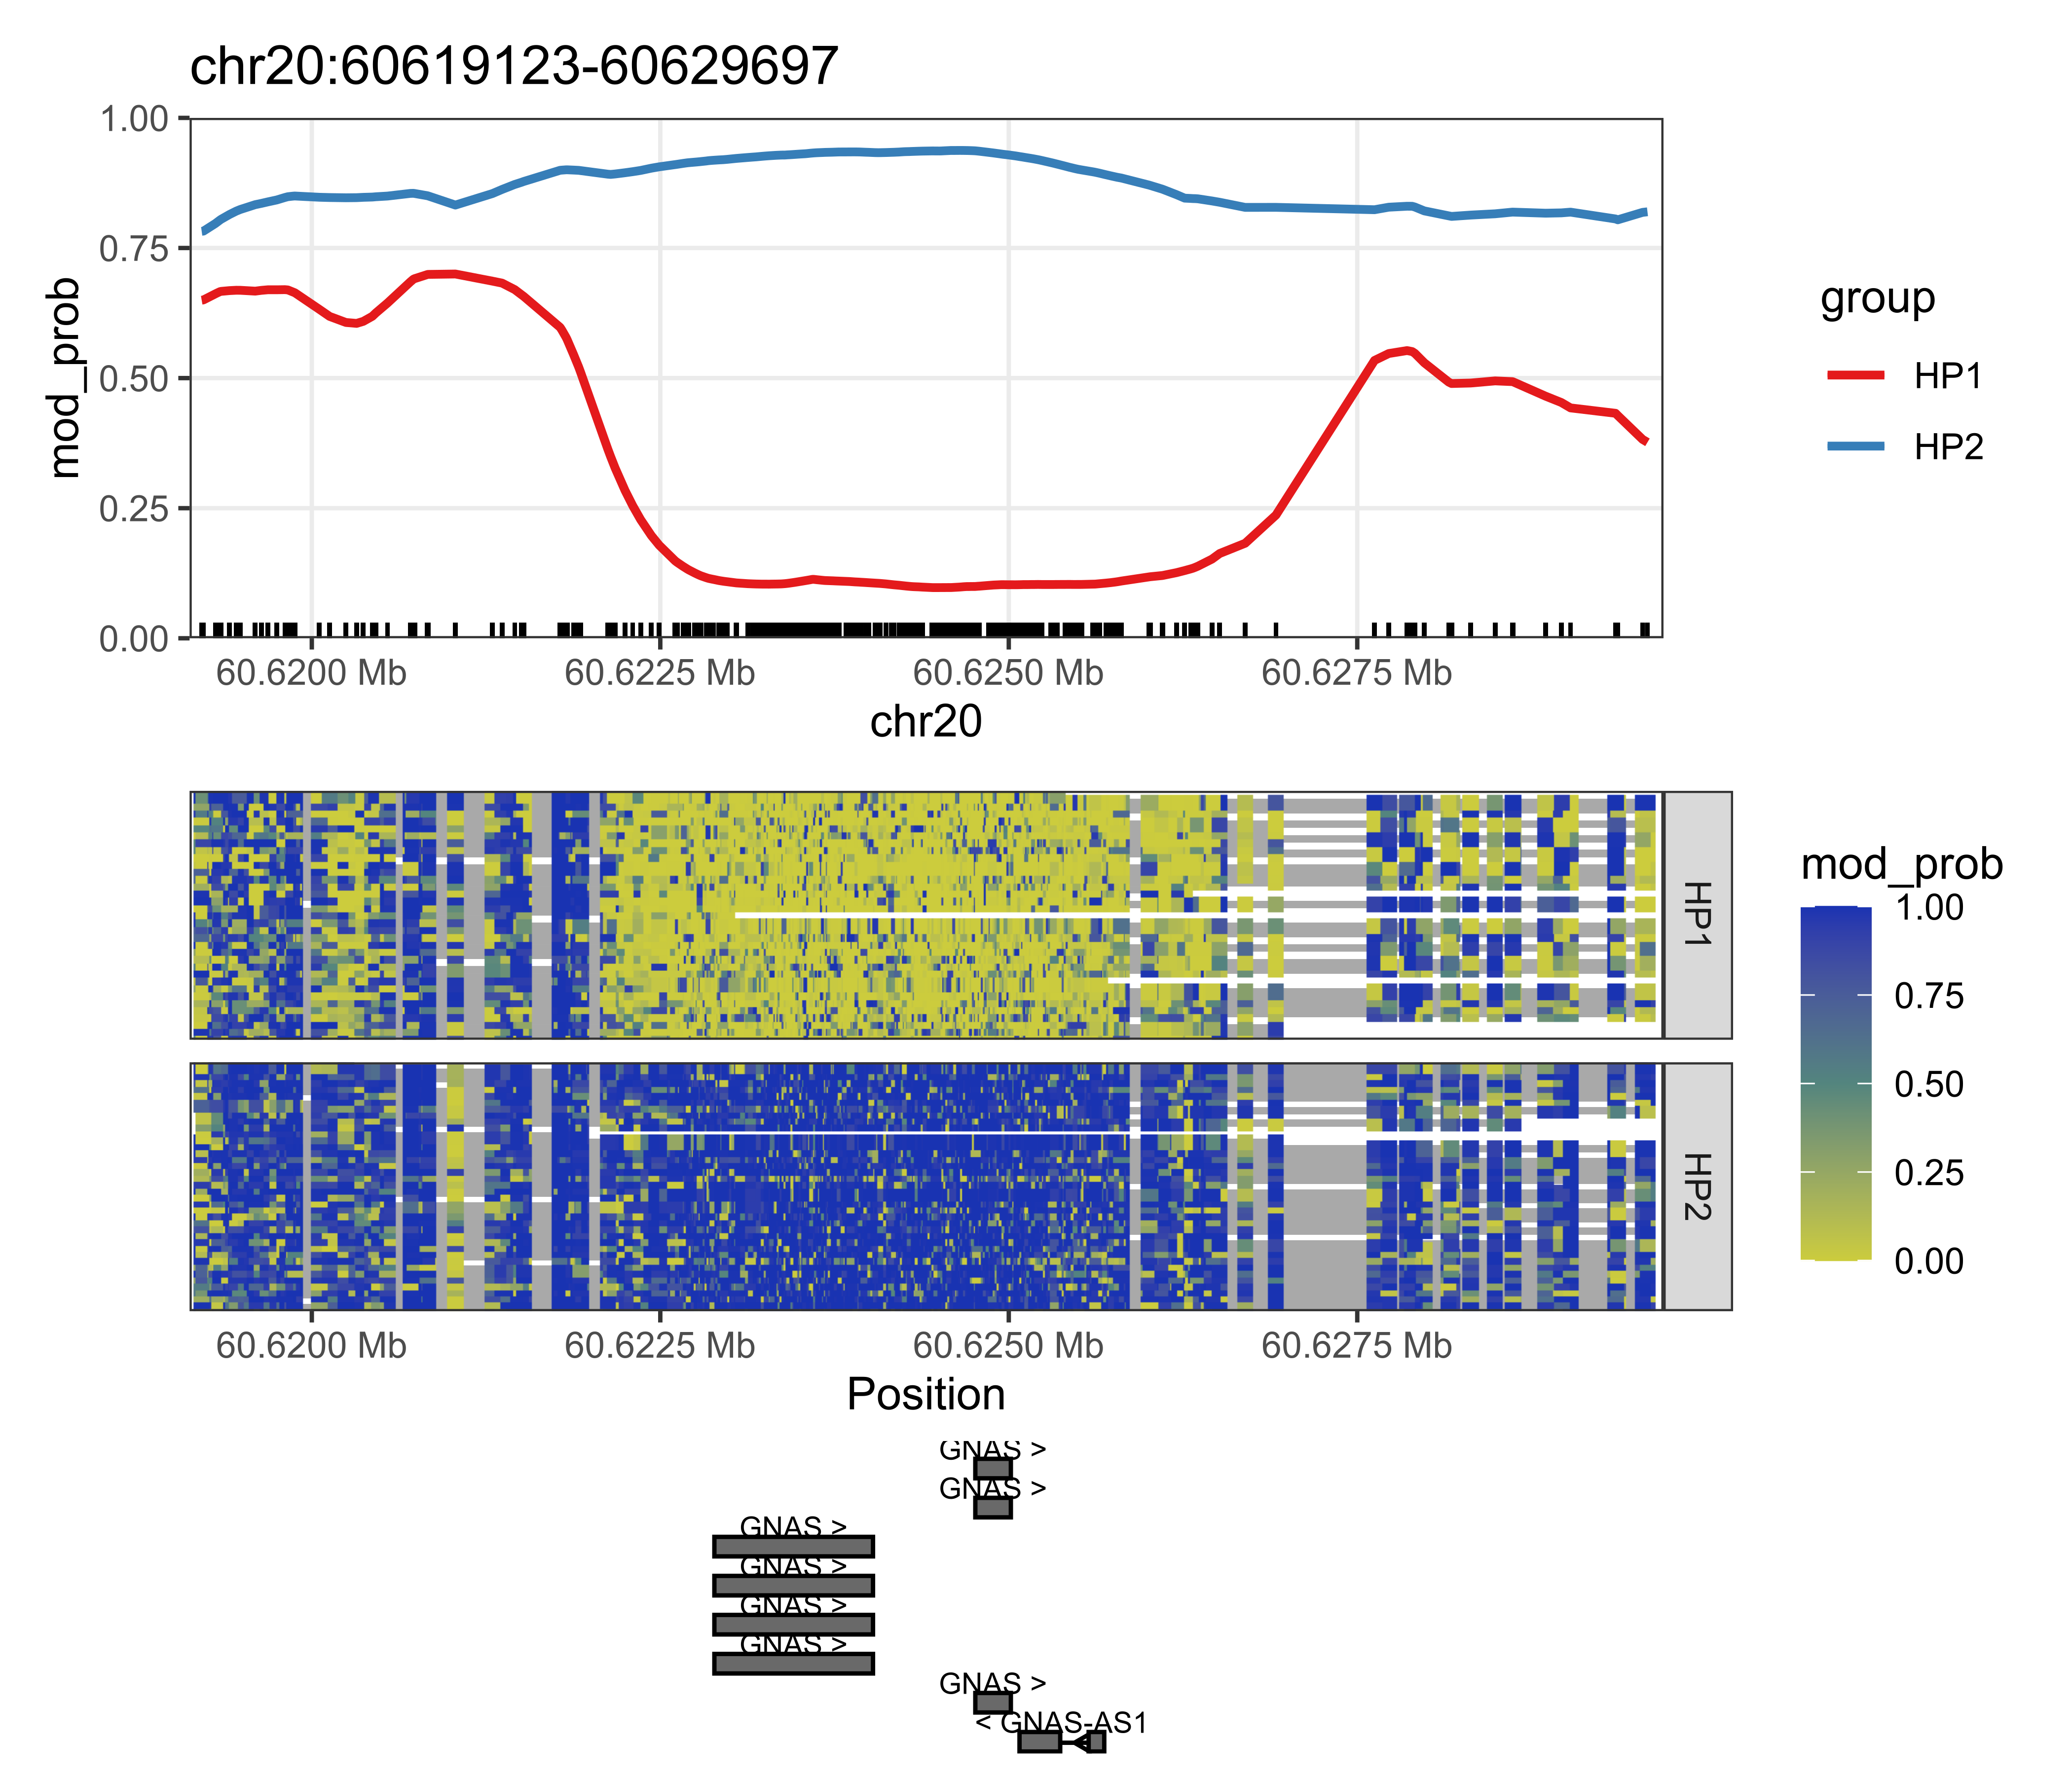

In [8]:
show('ed3b_agent_GNAS.png')